Iniciando análisis genómico e introgresión directa (Estilo Publicación)...

       RESULTADOS FINALES DEL TEST D      
 Hipótesis: (((PCH, ATN), PNO), OUT)
 Conteo Total Sitios ABBA : 82
 Conteo Total Sitios BABA : 81
 Estadístico D             : 0.0061
 Error Estándar (Bootstrap): 0.0808
 Z-score                   : 0.0759

Renderizando figura integrada con filogenia rectangular...


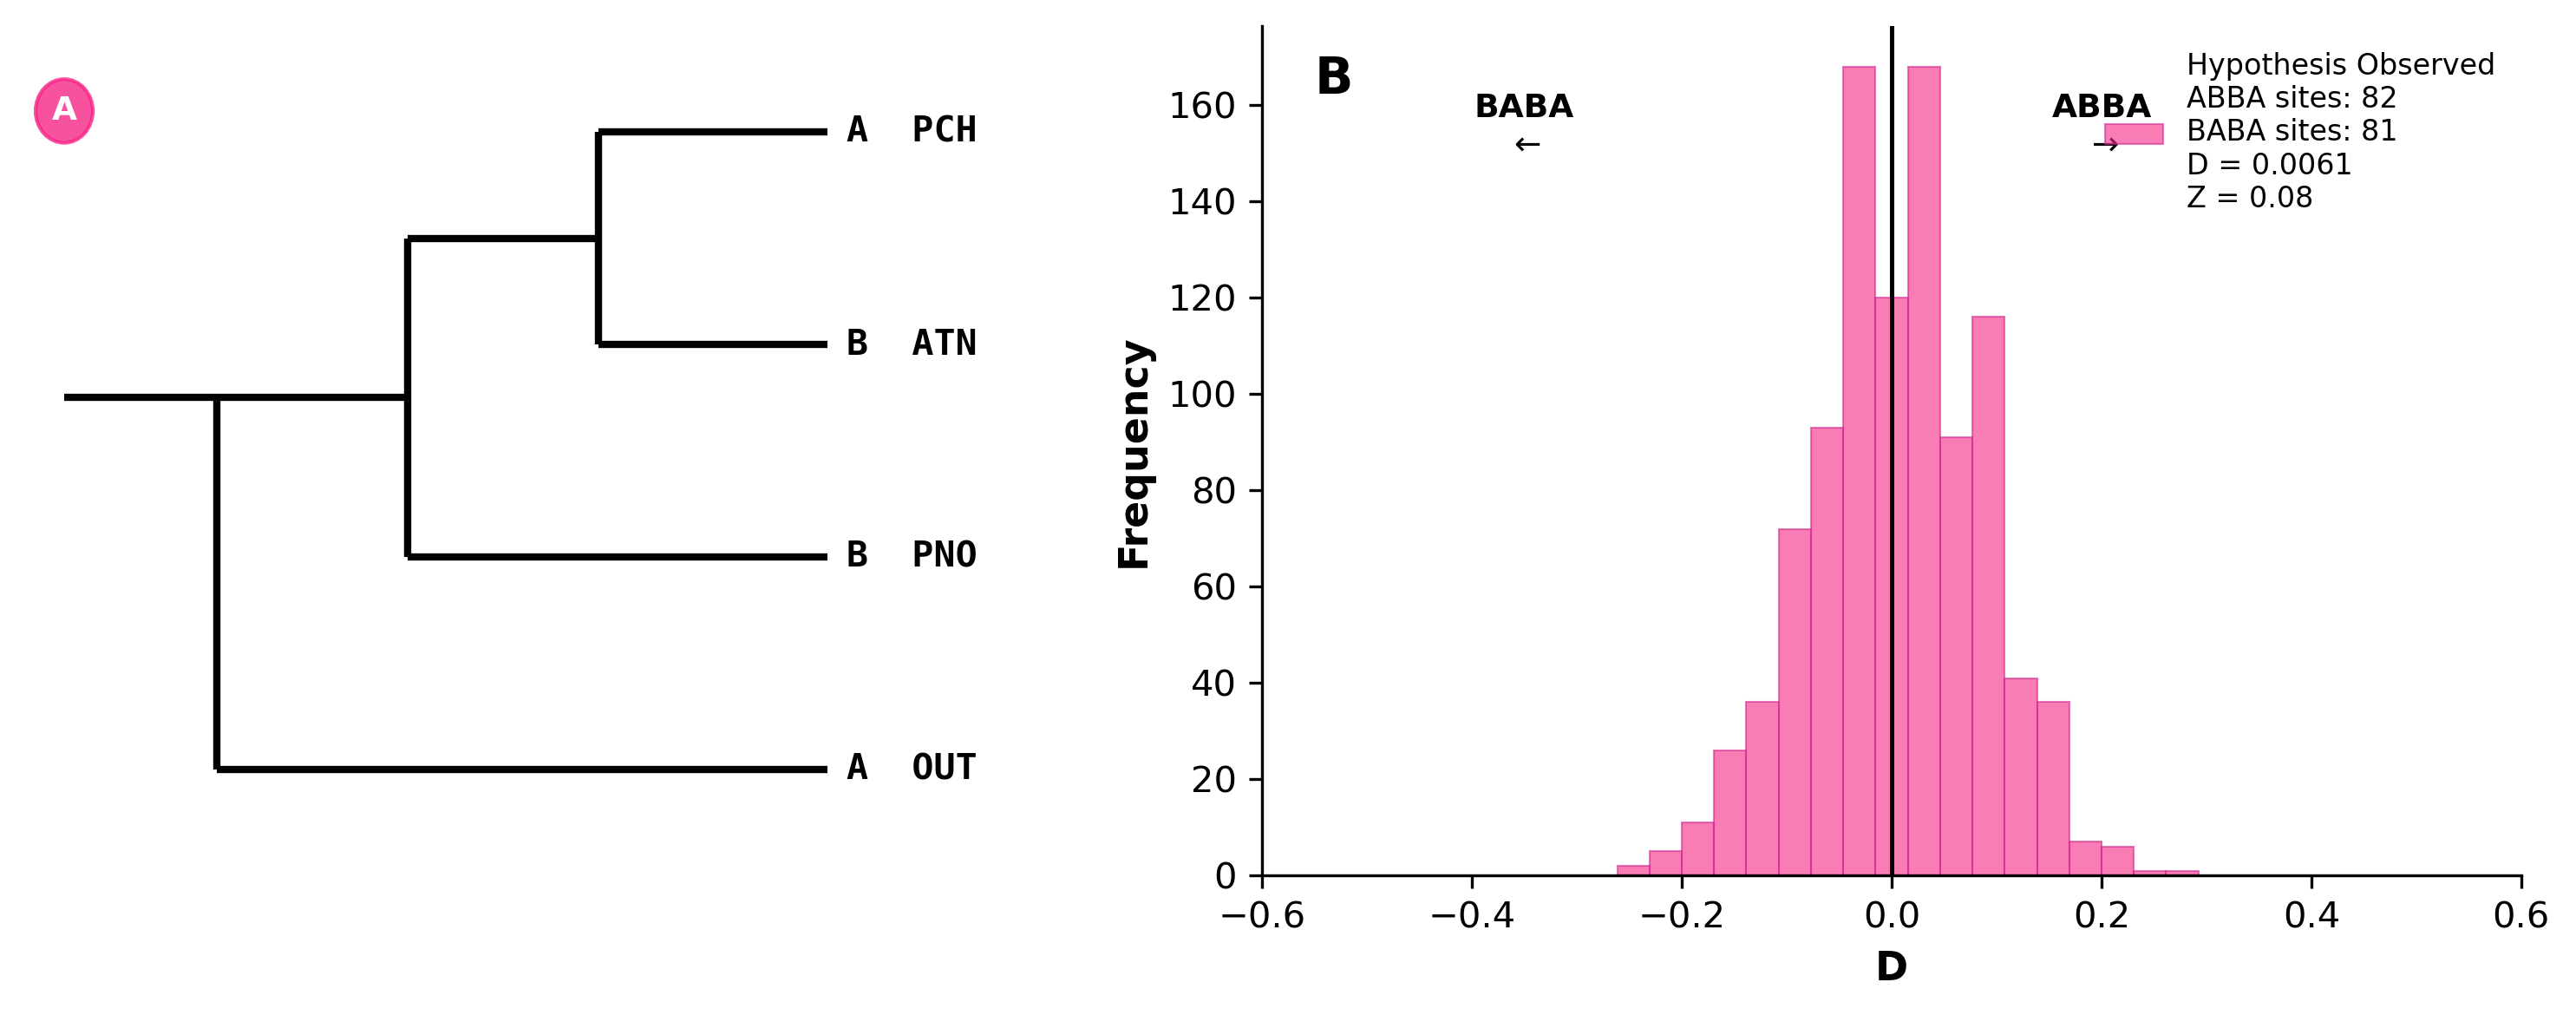

¡Figura guardada exitosamente como 'figura_compuesta_recta.png/.pdf'!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import toytree

print("Iniciando análisis genómico e introgresión directa (Estilo Publicación)...")

# ==========================================
# 1. CARGAR Y ENRAIZAR EL ÁRBOL FILOGENÉTICO
# ==========================================
ruta_arbol = "/Users/itziliwi/JN_ABBA-BABA_micro/00_inputs/micro_iqtree_01out_20250728.nwk"
tree_obj = toytree.tree(ruta_arbol) 
muestras_en_arbol = list(tree_obj.get_tip_labels())

# Enraizar el árbol usando la API de toytree v3 (.mod.root)
arbol_enraizado = tree_obj.root("eIm_002")
arbol_string = arbol_enraizado.write()


# ==========================================
# 2. CARGAR Y FILTRAR EL MAPA DE POBLACIONES (.TSV)
# ==========================================
ruta_tsv = "/Users/itziliwi/JN_ABBA-BABA_micro/00_inputs/poblacion_260702.tsv" 
df = pd.read_csv(ruta_tsv, sep="\t", header=0)
df.columns = ["muestra", "poblacion"]
df["muestra"] = df["muestra"].astype(str).str.strip()

poblaciones_por_muestra = dict(zip(df["muestra"], df["poblacion"]))

# Listas de muestras específicas por grupo de interés
P1 = [m for m, p in poblaciones_por_muestra.items() if p == "PCH"]
P2 = [m for m, p in poblaciones_por_muestra.items() if p == "ATN"]
P3 = [m for m, p in poblaciones_por_muestra.items() if p == "PNO"]
P4 = [m for m, p in poblaciones_por_muestra.items() if p == "OUT"]

ruta_loci = "/Users/itziliwi/JN_ABBA-BABA_micro/00_inputs/micro_c85_m95.loci"


# ==========================================
# 3. EXTRACCIÓN SÍNCRONA DE PATRONES EN EL .LOCI
# ==========================================
loci_data = []

with open(ruta_loci, "r") as f:
    locus_actual = {}
    for linea in f:
        linea_limpia = linea.strip()
        if not linea_limpia:
            continue
            
        if linea_limpia.startswith("//"):
            if all(any(m in locus_actual for m in group) for group in [P1, P2, P3, P4]):
                seq1 = next(locus_actual[m] for m in P1 if m in locus_actual)
                seq2 = next(locus_actual[m] for m in P2 if m in locus_actual)
                seq3 = next(locus_actual[m] for m in P3 if m in locus_actual)
                seq4 = next(locus_actual[m] for m in P4 if m in locus_actual)
                
                for n1, n2, n3, n4 in zip(seq1, seq2, seq3, seq4):
                    if '-' in (n1, n2, n3, n4) or 'N' in (n1, n2, n3, n4):
                        continue
                    # Patrón ABBA
                    if n1 == n4 and n2 == n3 and n2 != n4:
                        loci_data.append(1)
                    # Patrón BABA
                    elif n2 == n4 and n1 == n3 and n1 != n4:
                        loci_data.append(-1)
            locus_actual = {}
        else:
            parts = linea_limpia.split()
            if len(parts) == 2:
                locus_actual[parts[0].replace(">", "")] = parts[1]


# ==========================================
# 4. COMPRESIÓN ESTADÍSTICA Y BOOTSTRAP
# ==========================================
sitios_abba = loci_data.count(1)
sitios_baba = loci_data.count(-1)
total_sitios = sitios_abba + sitios_baba

if total_sitios == 0:
    print("Error: No se detectaron sitios informativos en las alineaciones.")
else:
    D = (sitios_abba - sitios_baba) / total_sitios
    
    # 1,000 repeticiones de remuestreo por bloques
    np.random.seed(42)
    arr_data = np.array(loci_data)
    boot_ds = []
    
    for _ in range(1000):
        boot_sample = np.random.choice(arr_data, size=len(arr_data), replace=True)
        n_abba = np.sum(boot_sample == 1)
        n_baba = np.sum(boot_sample == -1)
        if (n_abba + n_baba) > 0:
            boot_ds.append((n_abba - n_baba) / (n_abba + n_baba))
            
    std_err = np.std(boot_ds)
    z_score = D / std_err if std_err > 0 else 0
    
    print("\n==========================================")
    print("       RESULTADOS FINALES DEL TEST D      ")
    print("==========================================")
    print(f" Hipótesis: (((PCH, ATN), PNO), OUT)")
    print(f" Conteo Total Sitios ABBA : {sitios_abba}")
    print(f" Conteo Total Sitios BABA : {sitios_baba}")
    print(f" Estadístico D             : {D:.4f}")
    print(f" Error Estándar (Bootstrap): {std_err:.4f}")
    print(f" Z-score                   : {z_score:.4f}")
    print("==========================================\n")


       # ==========================================
    # 5. GENERAR FIGURA COMPUESTA CORREGIDA (RECTANGULAR Y SIN ERRORES)
    # ==========================================
    print("Renderizando figura integrada con filogenia rectangular...")
    
    # Inicializar lienzo con dos paneles (Árbol a la izquierda, Histograma a la derecha)
    fig, (ax_tree, ax_hist) = plt.subplots(1, 2, figsize=(10, 4), dpi=300, gridspec_kw={'width_ratios': [1, 1.2]})
    
    # --- PANEL A: ÁRBOL FILOGENÉTICO RECTANGULAR PERFECTO ---
    # Ramas horizontales que llegan a los taxones (Puntas)
    ax_tree.hlines(y=3.5, xmin=3.0, xmax=4.2, color='black', linewidth=2)  # P1 (PCH)
    ax_tree.hlines(y=2.5, xmin=3.0, xmax=4.2, color='black', linewidth=2)  # P2 (ATN)
    ax_tree.hlines(y=1.5, xmin=2.0, xmax=4.2, color='black', linewidth=2)  # P3 (PNO)
    ax_tree.hlines(y=0.5, xmin=1.0, xmax=4.2, color='black', linewidth=2)  # P4 (OUT)
    
    # Conexiones horizontales internas entre nodos
    ax_tree.hlines(y=3.0, xmin=2.0, xmax=3.0, color='black', linewidth=2)  # Ancestro P1-P2
    ax_tree.hlines(y=2.25, xmin=1.0, xmax=2.0, color='black', linewidth=2) # Ancestro P1-P2-P3
    ax_tree.hlines(y=2.25, xmin=0.2, xmax=1.0, color='black', linewidth=2) # Tronco principal (Raíz)

    # Líneas verticales que unen los nodos (Bifurcaciones)
    ax_tree.vlines(x=3.0, ymin=2.5, ymax=3.5, color='black', linewidth=2)  # Conecta P1 y P2
    ax_tree.vlines(x=2.0, ymin=1.5, ymax=3.0, color='black', linewidth=2)  # Conecta Clado P1-P2 con P3
    ax_tree.vlines(x=1.0, ymin=0.5, ymax=2.25, color='black', linewidth=2) # Conecta todo con el Outgroup P4
    
    # Nombres de las poblaciones y estados alélicos alineados
    ax_tree.text(4.3, 3.5, "A  PCH", fontsize=10, va='center', fontweight='bold', family='monospace')
    ax_tree.text(4.3, 2.5, "B  ATN", fontsize=10, va='center', fontweight='bold', family='monospace')
    ax_tree.text(4.3, 1.5, "B  PNO", fontsize=10, va='center', fontweight='bold', family='monospace')
    ax_tree.text(4.3, 0.5, "A  OUT", fontsize=10, va='center', fontweight='bold', family='monospace')
    
    # Círculo indicador decorativo del Panel A
    circulo = plt.Circle((0.2, 3.6), 0.15, color='#F72585', alpha=0.8)
    ax_tree.add_patch(circulo)
    ax_tree.text(0.2, 3.6, "A", color='white', fontsize=9, fontweight='bold', va='center', ha='center')
    
    # Ajustes de límites y apagado de ejes del panel izquierdo
    ax_tree.set_xlim(0, 5.5)
    ax_tree.set_ylim(0, 4.0)
    ax_tree.axis('off')
    
    
    # --- PANEL B: HISTOGRAMA DE FRECUENCIAS ---
    bins_eje = np.linspace(-0.6, 0.6, 40)
    color_hist = '#F72585' if abs(z_score) < 3 else '#4CC9F0'
    borde_hist = '#CD2990' if abs(z_score) < 3 else '#27408B'
    
    texto_leyenda = (
        f"Hypothesis Observed\n"
        f"ABBA sites: {sitios_abba}\n"
        f"BABA sites: {sitios_baba}\n"
        f"D = {D:.4f}\n"
        f"Z = {z_score:.2f}"
    )
    
    ax_hist.hist(
        boot_ds, 
        bins=bins_eje, 
        color=color_hist, 
        alpha=0.6, 
        edgecolor=borde_hist,
        linewidth=0.5,
        label=texto_leyenda
    )
    
    ax_hist.axvline(x=0, color='black', linewidth=1.2)
    
    # Altura máxima del histograma
    altura_max = ax_hist.get_ylim()[1]
    
    # MODIFICACIÓN AQUÍ: Reubicamos las etiquetas y flechas para que no choquen con la leyenda
    ax_hist.text(-0.35, altura_max * 0.85, r'BABA' + '\n' + r'$\leftarrow$', fontsize=9, fontweight='bold', ha='center')
    ax_hist.text(0.20, altura_max * 0.85, r'ABBA' + '\n' + r'$\rightarrow$', fontsize=9, fontweight='bold', ha='center') # <-- Movido de 0.35 a 0.20
    
    ax_hist.set_xlim(-0.6, 0.6)
    ax_hist.set_xlabel('D', fontsize=11, fontweight='bold')
    ax_hist.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    
    # MODIFICACIÓN AQUÍ: Ajustamos la leyenda para que se alinee perfectamente a la derecha externa
    ax_hist.legend(loc='upper right', fontsize=8, frameon=False, bbox_to_anchor=(1.0, 1.0))
    
    ax_hist.spines['top'].set_visible(False)
    ax_hist.spines['right'].set_visible(False)
    ax_hist.text(-0.55, altura_max * 0.92, "B", fontsize=14, fontweight='bold')

    
    plt.tight_layout()
    
    # Guardar archivos
  #  plt.savefig('figura_compuesta_recta.png', bbox_inches='tight', dpi=300)
   # plt.savefig('figura_compuesta_recta.pdf', bbox_inches='tight')
    
    plt.show()
    print("¡Figura guardada exitosamente como 'figura_compuesta_recta.png/.pdf'!")



In [2]:
# 1. Contar cuántos individuos hay en cada población (Ordenados de mayor a menor)
conteo_poblaciones = df["poblacion"].value_counts()

print("==========================================")
print("     NÚMERO DE INDIVIDUOS POR POBLACIÓN   ")
print("==========================================")
print(conteo_poblaciones.to_string())
print("==========================================")
print(f"Total de individuos en el archivo: {len(df)}")


     NÚMERO DE INDIVIDUOS POR POBLACIÓN   
poblacion
ATN    34
PCE    32
PNO    23
ISN    23
PCH    15
POO    10
ACE     9
ACO     9
OUT     8
PSU     8
IST     8
POR     7
Total de individuos en el archivo: 186


In [1]:
#### probando la hipotesis (((ATN, cualquiera) PNO, OUT))

Iniciando análisis genómico e introgresión múltiple (Estilo Publicación)...
Cargando archivo .loci en memoria...

Procesando combinación: (((ATN, PSU), PNO), OUT)...
       RESULTADOS FINALES DEL TEST D      
 Hipótesis: (((ATN, PSU), PNO), OUT)
 Conteo Total Sitios ABBA : 167
 Conteo Total Sitios BABA : 161
 Estadístico D             : 0.0183
 Error Estándar (Bootstrap): 0.0542
 Z-score                   : 0.3375
 Significancia: No hay evidencia de flujo génico (ILS o estructura ancestral).


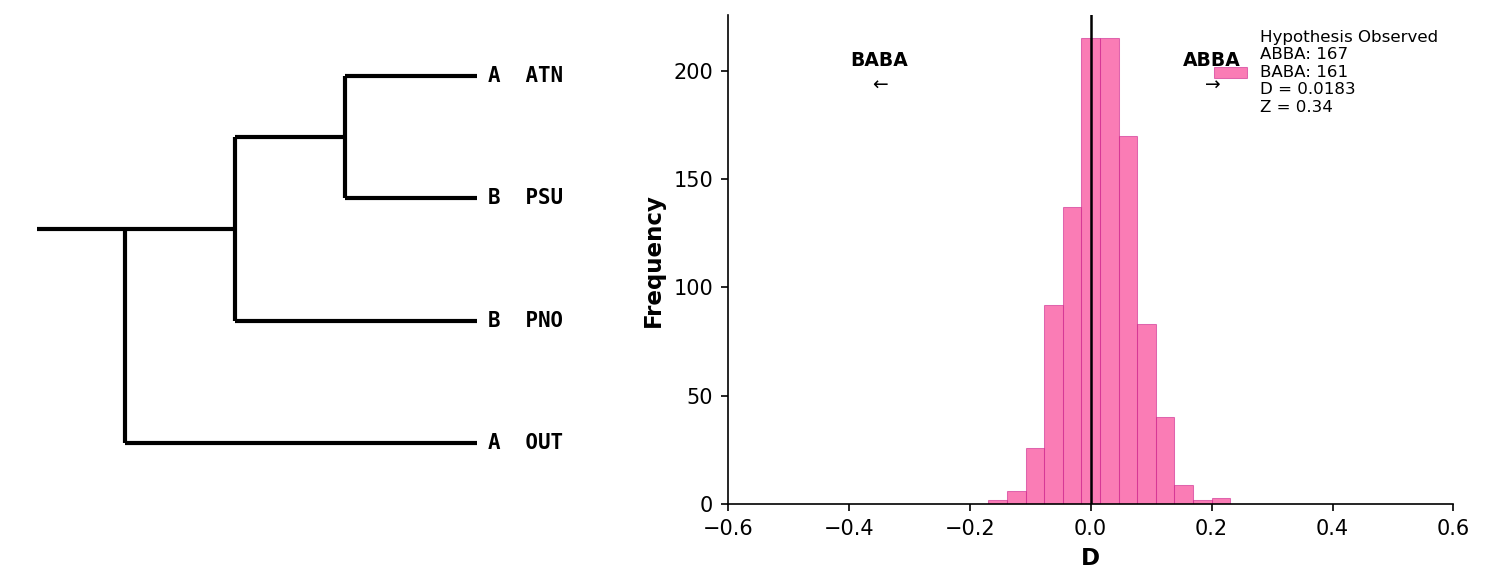


Procesando combinación: (((ATN, PCE), PNO), OUT)...
       RESULTADOS FINALES DEL TEST D      
 Hipótesis: (((ATN, PCE), PNO), OUT)
 Conteo Total Sitios ABBA : 222
 Conteo Total Sitios BABA : 152
 Estadístico D             : 0.1872
 Error Estándar (Bootstrap): 0.0500
 Z-score                   : 3.7427
 Significancia: Flujo génico significativo entre PCE y PNO


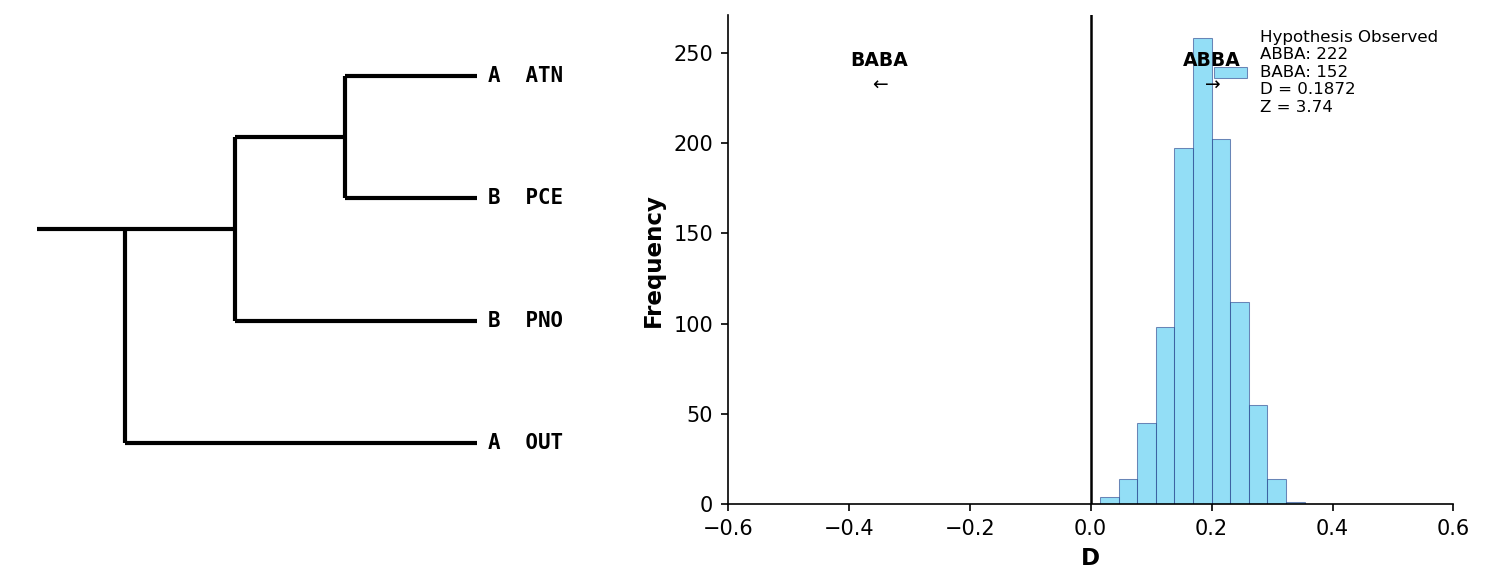


Procesando combinación: (((ATN, PCH), PNO), OUT)...
       RESULTADOS FINALES DEL TEST D      
 Hipótesis: (((ATN, PCH), PNO), OUT)
 Conteo Total Sitios ABBA : 81
 Conteo Total Sitios BABA : 82
 Estadístico D             : -0.0061
 Error Estándar (Bootstrap): 0.0808
 Z-score                   : -0.0759
 Significancia: No hay evidencia de flujo génico (ILS o estructura ancestral).


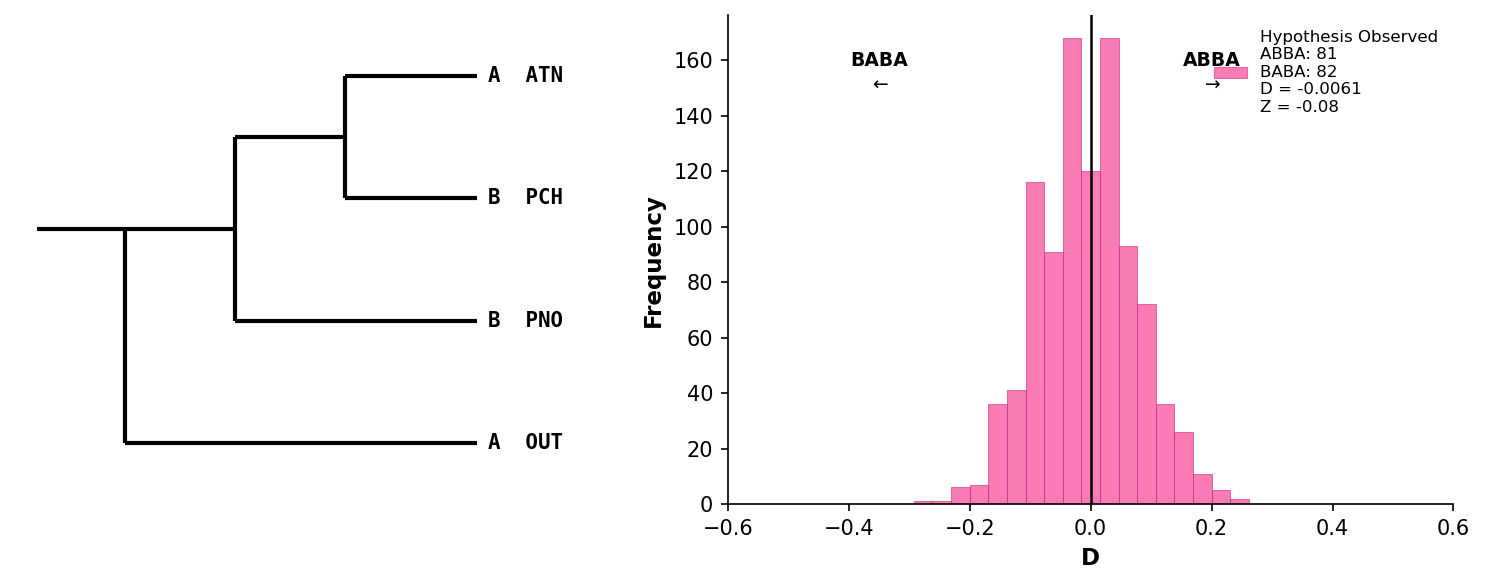


Procesando combinación: (((ATN, POO), PNO), OUT)...
       RESULTADOS FINALES DEL TEST D      
 Hipótesis: (((ATN, POO), PNO), OUT)
 Conteo Total Sitios ABBA : 195
 Conteo Total Sitios BABA : 155
 Estadístico D             : 0.1143
 Error Estándar (Bootstrap): 0.0524
 Z-score                   : 2.1795
 Significancia: No hay evidencia de flujo génico (ILS o estructura ancestral).


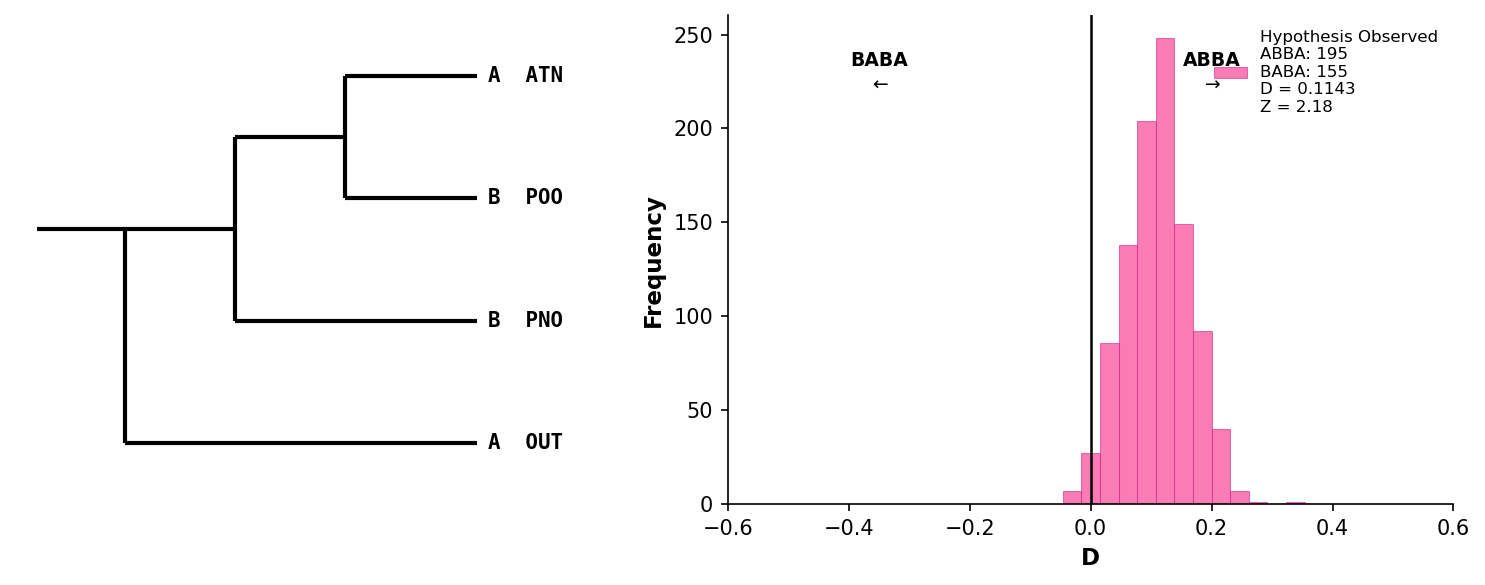


Procesando combinación: (((ATN, ISN), PNO), OUT)...
       RESULTADOS FINALES DEL TEST D      
 Hipótesis: (((ATN, ISN), PNO), OUT)
 Conteo Total Sitios ABBA : 93
 Conteo Total Sitios BABA : 97
 Estadístico D             : -0.0211
 Error Estándar (Bootstrap): 0.0715
 Z-score                   : -0.2945
 Significancia: No hay evidencia de flujo génico (ILS o estructura ancestral).


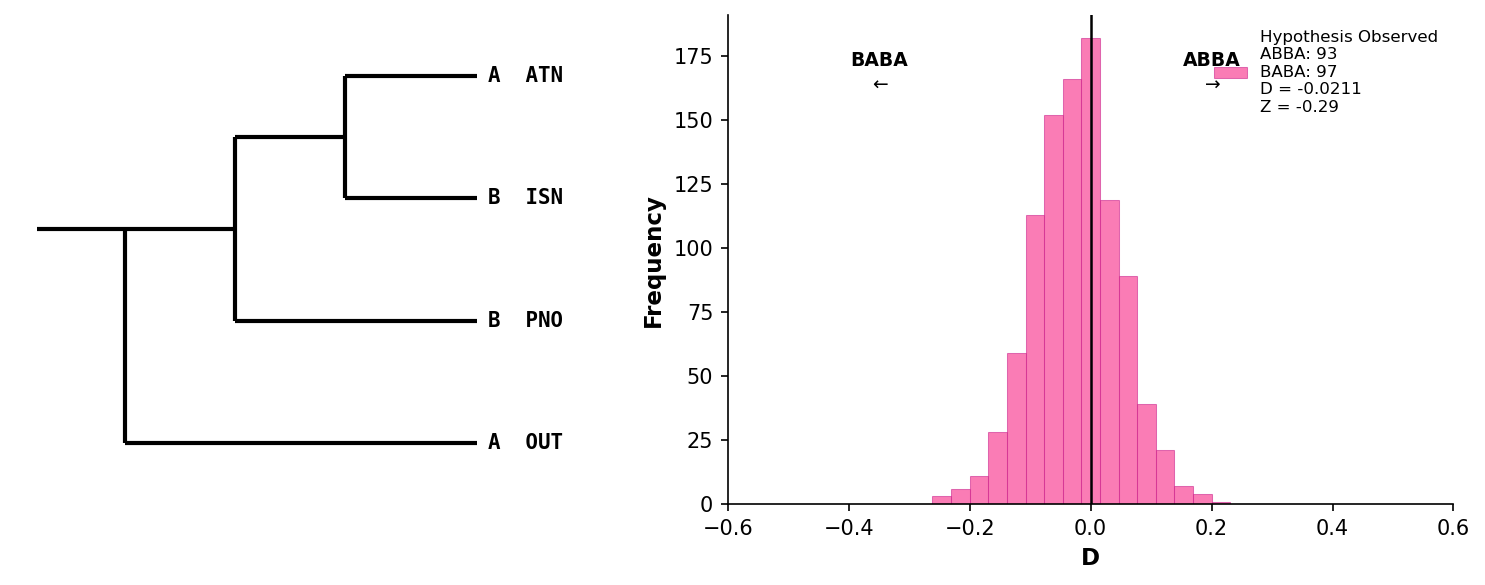


Procesando combinación: (((ATN, IST), PNO), OUT)...
       RESULTADOS FINALES DEL TEST D      
 Hipótesis: (((ATN, IST), PNO), OUT)
 Conteo Total Sitios ABBA : 117
 Conteo Total Sitios BABA : 80
 Estadístico D             : 0.1878
 Error Estándar (Bootstrap): 0.0702
 Z-score                   : 2.6767
 Significancia: No hay evidencia de flujo génico (ILS o estructura ancestral).


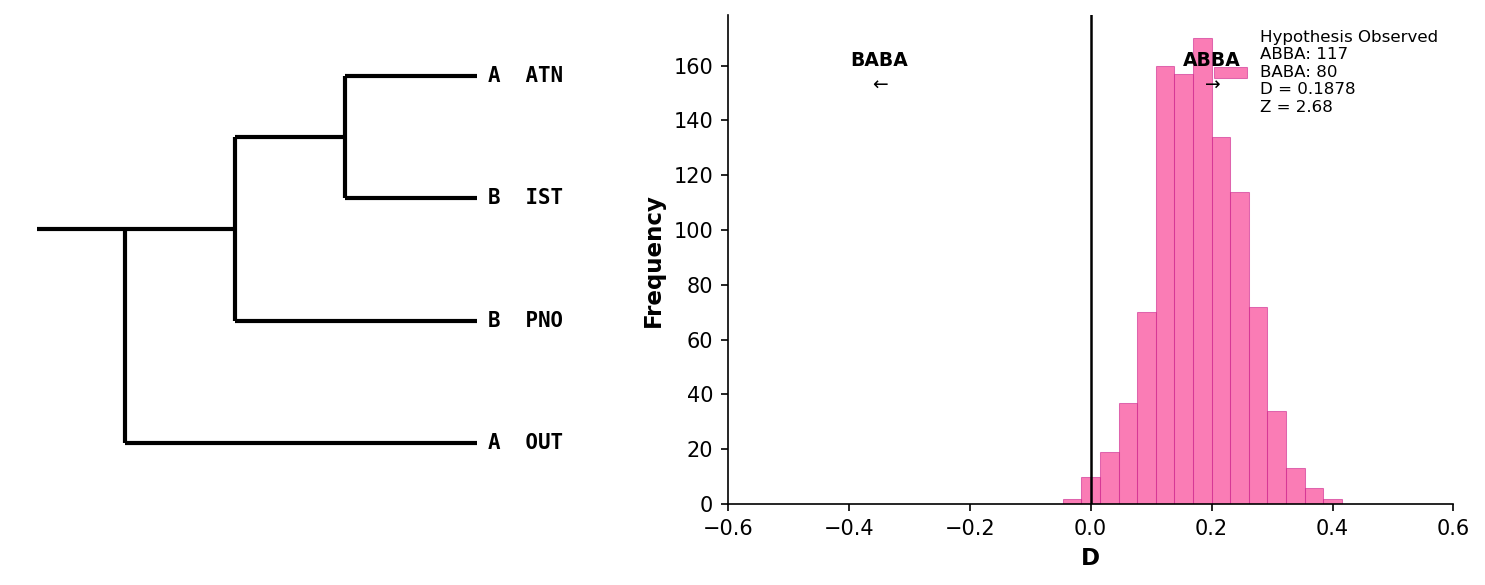


Procesando combinación: (((ATN, ACE), PNO), OUT)...
       RESULTADOS FINALES DEL TEST D      
 Hipótesis: (((ATN, ACE), PNO), OUT)
 Conteo Total Sitios ABBA : 109
 Conteo Total Sitios BABA : 97
 Estadístico D             : 0.0583
 Error Estándar (Bootstrap): 0.0702
 Z-score                   : 0.8300
 Significancia: No hay evidencia de flujo génico (ILS o estructura ancestral).


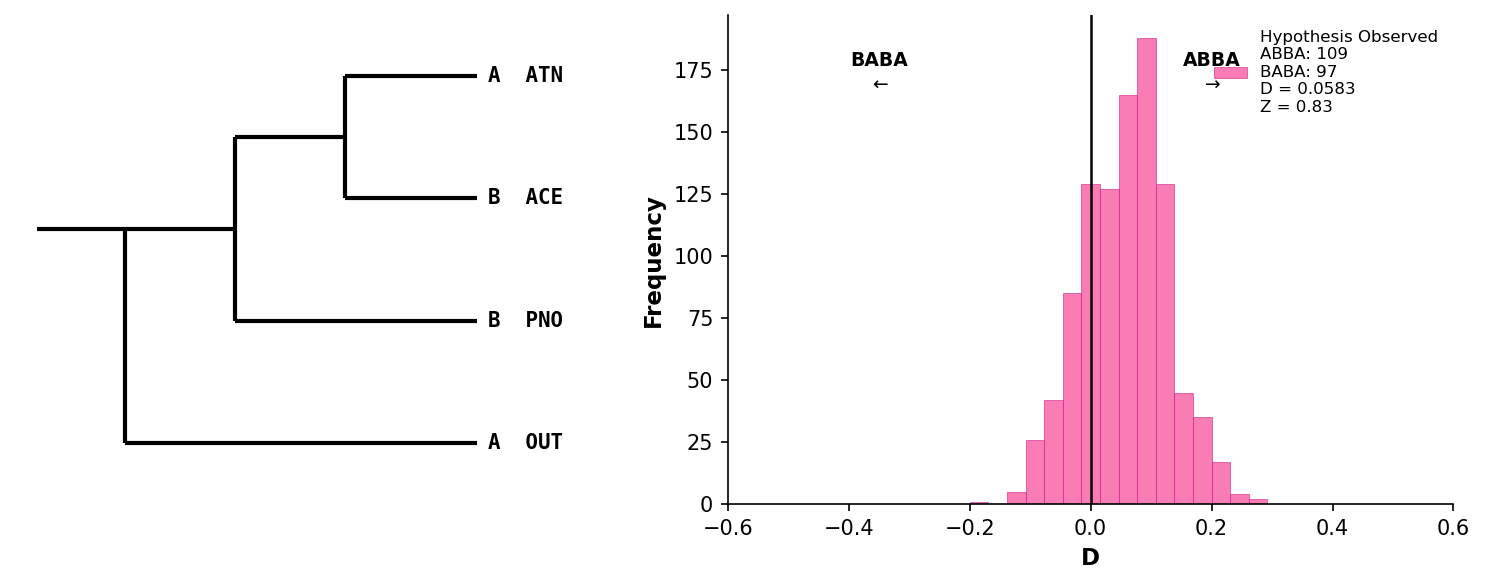


Procesando combinación: (((ATN, POR), PNO), OUT)...
       RESULTADOS FINALES DEL TEST D      
 Hipótesis: (((ATN, POR), PNO), OUT)
 Conteo Total Sitios ABBA : 191
 Conteo Total Sitios BABA : 168
 Estadístico D             : 0.0641
 Error Estándar (Bootstrap): 0.0534
 Z-score                   : 1.1993
 Significancia: No hay evidencia de flujo génico (ILS o estructura ancestral).


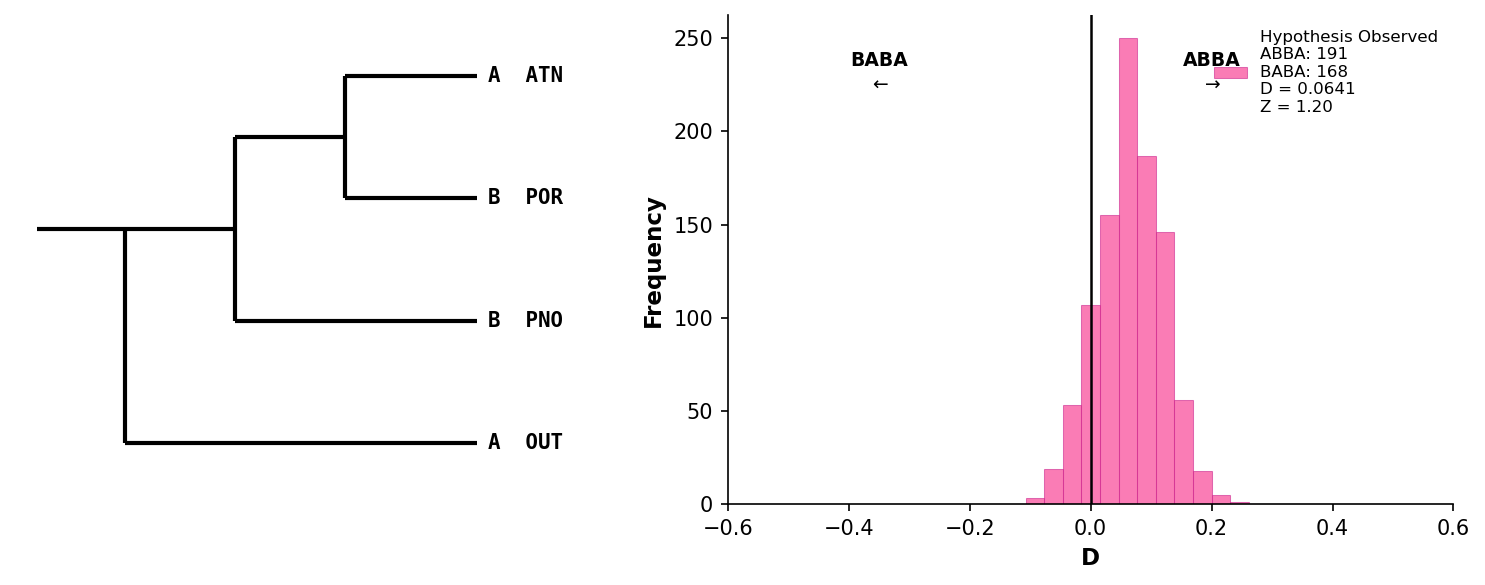


Procesando combinación: (((ATN, ACO), PNO), OUT)...
       RESULTADOS FINALES DEL TEST D      
 Hipótesis: (((ATN, ACO), PNO), OUT)
 Conteo Total Sitios ABBA : 123
 Conteo Total Sitios BABA : 111
 Estadístico D             : 0.0513
 Error Estándar (Bootstrap): 0.0657
 Z-score                   : 0.7808
 Significancia: No hay evidencia de flujo génico (ILS o estructura ancestral).


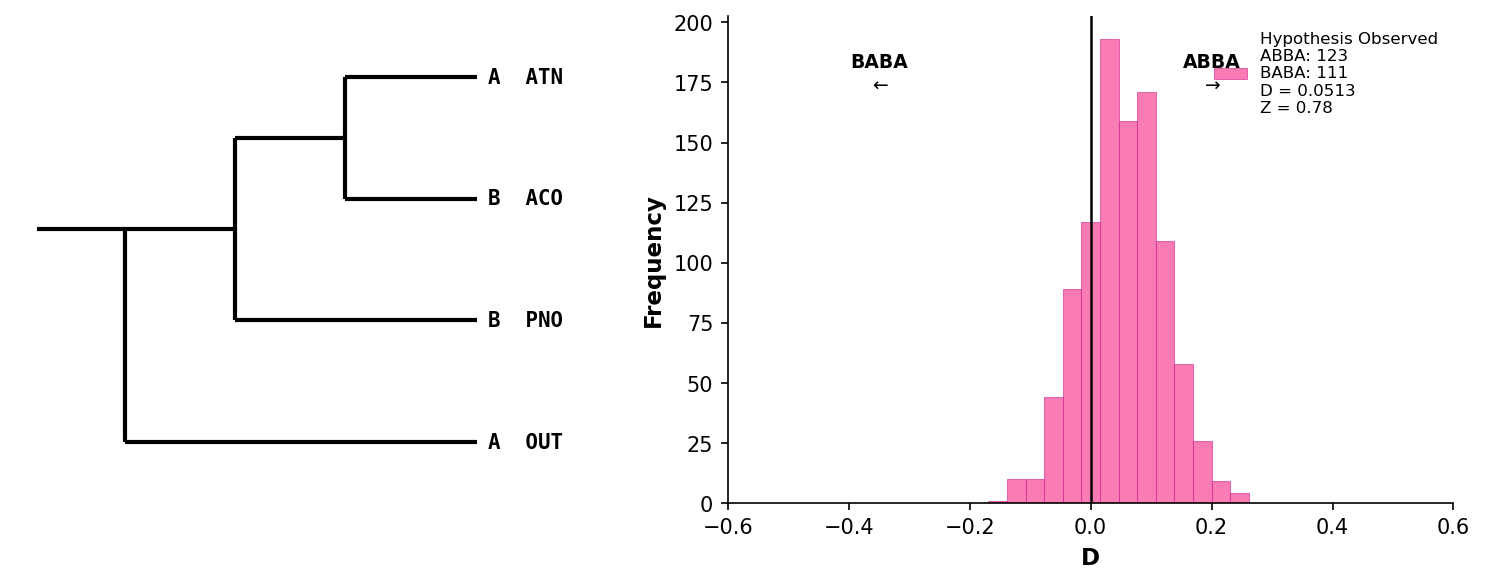


¡Análisis de todas las combinaciones completado con éxito!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import toytree

print("Iniciando análisis genómico e introgresión múltiple (Estilo Publicación)...")

# ==========================================
# 1. CARGAR Y ENRAIZAR EL ÁRBOL FILOGENÉTICO
# ==========================================
ruta_arbol = "/Users/itziliwi/JN_ABBA-BABA_micro/00_inputs/micro_iqtree_01out_20250728.nwk"
tree_obj = toytree.tree(ruta_arbol) 
muestras_en_arbol = list(tree_obj.get_tip_labels())

# Enraizar el árbol usando la API de toytree v3 (.mod.root)
arbol_enraizado = tree_obj.root("eIm_002")
arbol_string = arbol_enraizado.write()


# ==========================================
# 2. CARGAR MAPA DE POBLACIONES Y CONFIGURAR ROLES
# ==========================================
ruta_tsv = "/Users/itziliwi/JN_ABBA-BABA_micro/00_inputs/poblacion_260702.tsv" 
df = pd.read_csv(ruta_tsv, sep="\t", header=0)
df.columns = ["muestra", "poblacion"]
df["muestra"] = df["muestra"].astype(str).str.strip()
df["poblacion"] = df["poblacion"].astype(str).str.strip()

poblaciones_por_muestra = dict(zip(df["muestra"], df["poblacion"]))

# Definir poblaciones fijas según tu nueva hipótesis
pob_P1 = "ATN"
pob_P3 = "PNO"
pob_P4 = "OUT"

# Obtener todas las poblaciones candidatas para P2 (excluyendo las fijas)
todas_las_poblaciones = df["poblacion"].unique()
poblaciones_P2 = [p for p in todas_las_poblaciones if p not in [pob_P1, pob_P3, pob_P4]]

# Asignar listas de muestras para las poblaciones fijas
muestras_P1 = [m for m, p in poblaciones_por_muestra.items() if p == pob_P1]
muestras_P3 = [m for m, p in poblaciones_por_muestra.items() if p == pob_P3]
muestras_P4 = [m for m, p in poblaciones_por_muestra.items() if p == pob_P4]


# ==========================================
# 3. LEER EL ARCHIVO .LOCI EN MEMORIA (OPTIMIZACIÓN)
# ==========================================
# Almacenamos los loci en una lista de diccionarios para no re-leer el disco en cada iteración
ruta_loci = "/Users/itziliwi/JN_ABBA-BABA_micro/00_inputs/micro_c85_m95.loci"
print("Cargando archivo .loci en memoria...")

todos_los_loci = []
with open(ruta_loci, "r") as f:
    locus_actual = {}
    for linea in f:
        linea_limpia = linea.strip()
        if not linea_limpia:
            continue
        if linea_limpia.startswith("//"):
            if locus_actual:
                todos_los_loci.append(locus_actual)
            locus_actual = {}
        else:
            parts = linea_limpia.split()
            if len(parts) == 2:
                locus_actual[parts[0].replace(">", "")] = parts[1]


# ==========================================
# 4. ITERAR SOBRE CADA CANDIDATO PARA P2
# ==========================================
for pob_P2 in poblaciones_P2:
    print(f"\nProcesando combinación: ((({pob_P1}, {pob_P2}), {pob_P3}), {pob_P4})...")
    
    # Obtener muestras de la P2 actual
    muestras_P2 = [m for m, p in poblaciones_por_muestra.items() if p == pob_P2]
    
    # Si la población no tiene muestras asignadas, saltar
    if not muestras_P2:
        print(f"Saltando {pob_P2}: No se encontraron muestras.")
        continue
        
    loci_data = []
    
    # Procesar los loci guardados en memoria
    for locus in todos_los_loci:
        # Verificar que el locus tenga al menos una muestra de cada población requerida
        if (any(m in locus for m in muestras_P1) and 
            any(m in locus for m in muestras_P2) and 
            any(m in locus for m in muestras_P3) and 
            any(m in locus for m in muestras_P4)):
            
            seq1 = next(locus[m] for m in muestras_P1 if m in locus)
            seq2 = next(locus[m] for m in muestras_P2 if m in locus)
            seq3 = next(locus[m] for m in muestras_P3 if m in locus)
            seq4 = next(locus[m] for m in muestras_P4 if m in locus)
            
            for n1, n2, n3, n4 in zip(seq1, seq2, seq3, seq4):
                if '-' in (n1, n2, n3, n4) or 'N' in (n1, n2, n3, n4):
                    continue
                # Patrón ABBA
                if n1 == n4 and n2 == n3 and n2 != n4:
                    loci_data.append(1)
                # Patrón BABA
                elif n2 == n4 and n1 == n3 and n1 != n4:
                    loci_data.append(-1)

    # ==========================================
    # 5. CÁLCULO ESTADÍSTICO Y BOOTSTRAP
    # ==========================================
    sitios_abba = loci_data.count(1)
    sitios_baba = loci_data.count(-1)
    total_sitios = sitios_abba + sitios_baba
    
    if total_sitios == 0:
        print(f"No se detectaron sitios informativos para la combinación con {pob_P2}.")
        continue
        
    D = (sitios_abba - sitios_baba) / total_sitios
    
    # Bootstrap
    np.random.seed(42)
    arr_data = np.array(loci_data)
    boot_ds = []
    
    for _ in range(1000):
        boot_sample = np.random.choice(arr_data, size=len(arr_data), replace=True)
        n_abba = np.sum(boot_sample == 1)
        n_baba = np.sum(boot_sample == -1)
        if (n_abba + n_baba) > 0:
            boot_ds.append((n_abba - n_baba) / (n_abba + n_baba))
            
    std_err = np.std(boot_ds) if len(boot_ds) > 0 else 0
    z_score = D / std_err if std_err > 0 else 0
    
    # Imprimir resultados en consola
    print("==========================================")
    print("       RESULTADOS FINALES DEL TEST D      ")
    print("==========================================")
    print(f" Hipótesis: ((({pob_P1}, {pob_P2}), {pob_P3}), {pob_P4})")
    print(f" Conteo Total Sitios ABBA : {sitios_abba}")
    print(f" Conteo Total Sitios BABA : {sitios_baba}")
    print(f" Estadístico D             : {D:.4f}")
    print(f" Error Estándar (Bootstrap): {std_err:.4f}")
    print(f" Z-score                   : {z_score:.4f}")
    if abs(z_score) >= 3:
        pob_flujo = pob_P2 if z_score > 0 else pob_P1
        print(f" Significancia: Flujo génico significativo entre {pob_flujo} y {pob_P3}")
    else:
        print(" Significancia: No hay evidencia de flujo génico (ILS o estructura ancestral).")
    print("==========================================")

    # ==========================================
    # 6. GENERAR GRÁFICO AUTOMÁTICO POR COMBINACIÓN
    # ==========================================
    fig, (ax_tree, ax_hist) = plt.subplots(1, 2, figsize=(10, 4), dpi=150, gridspec_kw={'width_ratios': [1, 1.2]})
    
    # PANEL A: Árbol Filogenético Dinámico
    ax_tree.hlines(y=3.5, xmin=3.0, xmax=4.2, color='black', linewidth=2)  # P1
    ax_tree.hlines(y=2.5, xmin=3.0, xmax=4.2, color='black', linewidth=2)  # P2
    ax_tree.hlines(y=1.5, xmin=2.0, xmax=4.2, color='black', linewidth=2)  # P3
    ax_tree.hlines(y=0.5, xmin=1.0, xmax=4.2, color='black', linewidth=2)  # P4
    
    ax_tree.hlines(y=3.0, xmin=2.0, xmax=3.0, color='black', linewidth=2)
    ax_tree.hlines(y=2.25, xmin=1.0, xmax=2.0, color='black', linewidth=2)
    ax_tree.hlines(y=2.25, xmin=0.2, xmax=1.0, color='black', linewidth=2)
    
    ax_tree.vlines(x=3.0, ymin=2.5, ymax=3.5, color='black', linewidth=2)
    ax_tree.vlines(x=2.0, ymin=1.5, ymax=3.0, color='black', linewidth=2)
    ax_tree.vlines(x=1.0, ymin=0.5, ymax=2.25, color='black', linewidth=2)
    
    ax_tree.text(4.3, 3.5, f"A  {pob_P1}", fontsize=10, va='center', fontweight='bold', family='monospace')
    ax_tree.text(4.3, 2.5, f"B  {pob_P2}", fontsize=10, va='center', fontweight='bold', family='monospace')
    ax_tree.text(4.3, 1.5, f"B  {pob_P3}", fontsize=10, va='center', fontweight='bold', family='monospace')
    ax_tree.text(4.3, 0.5, f"A  {pob_P4}", fontsize=10, va='center', fontweight='bold', family='monospace')
    
    ax_tree.set_xlim(0, 5.5)
    ax_tree.set_ylim(0, 4.0)
    ax_tree.axis('off')
    
    # PANEL B: Histograma
    bins_eje = np.linspace(-0.6, 0.6, 40)
    color_hist = '#4CC9F0' if abs(z_score) >= 3 else '#F72585'
    borde_hist = '#27408B' if abs(z_score) >= 3 else '#CD2990'
    
    texto_leyenda = f"Hypothesis Observed\nABBA: {sitios_abba}\nBABA: {sitios_baba}\nD = {D:.4f}\nZ = {z_score:.2f}"
    
    ax_hist.hist(boot_ds, bins=bins_eje, color=color_hist, alpha=0.6, edgecolor=borde_hist, linewidth=0.5, label=texto_leyenda)
    ax_hist.axvline(x=0, color='black', linewidth=1.2)
    
    altura_max = ax_hist.get_ylim()[1] if ax_hist.get_ylim()[1] > 0 else 1
    ax_hist.text(-0.35, altura_max * 0.85, 'BABA\n$\\leftarrow$', fontsize=9, fontweight='bold', ha='center')
    ax_hist.text(0.20, altura_max * 0.85, 'ABBA\n$\\rightarrow$', fontsize=9, fontweight='bold', ha='center')
    
    ax_hist.set_xlim(-0.6, 0.6)
    ax_hist.set_xlabel('D', fontsize=11, fontweight='bold')
    ax_hist.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax_hist.legend(loc='upper right', fontsize=8, frameon=False, bbox_to_anchor=(1.0, 1.0))
    ax_hist.spines['top'].set_visible(False)
    ax_hist.spines['right'].set_visible(False)
    
    plt.tight_layout()
    # Descomenta las líneas de abajo si quieres guardar los gráficos automáticamente
    # plt.savefig(f'figura_compuesta_{pob_P2}.png', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()

print("\n¡Análisis de todas las combinaciones completado con éxito!")

In [ ]:
#### probando la hipotesis (((cualquiera, ATN) PNO, OUT))

Iniciando análisis genómico e introgresión múltiple (Estilo Publicación)...
Cargando archivo .loci en memoria...

Procesando combinación: (((PSU, ATN), PNO), OUT)...
       RESULTADOS FINALES DEL TEST D      
 Hipótesis: (((PSU, ATN), PNO), OUT)
 Conteo Total Sitios ABBA : 161
 Conteo Total Sitios BABA : 167
 Estadístico D             : -0.0183
 Error Estándar (Bootstrap): 0.0542
 Z-score                   : -0.3375
 Significancia: No hay evidencia de flujo génico (ILS o estructura ancestral).


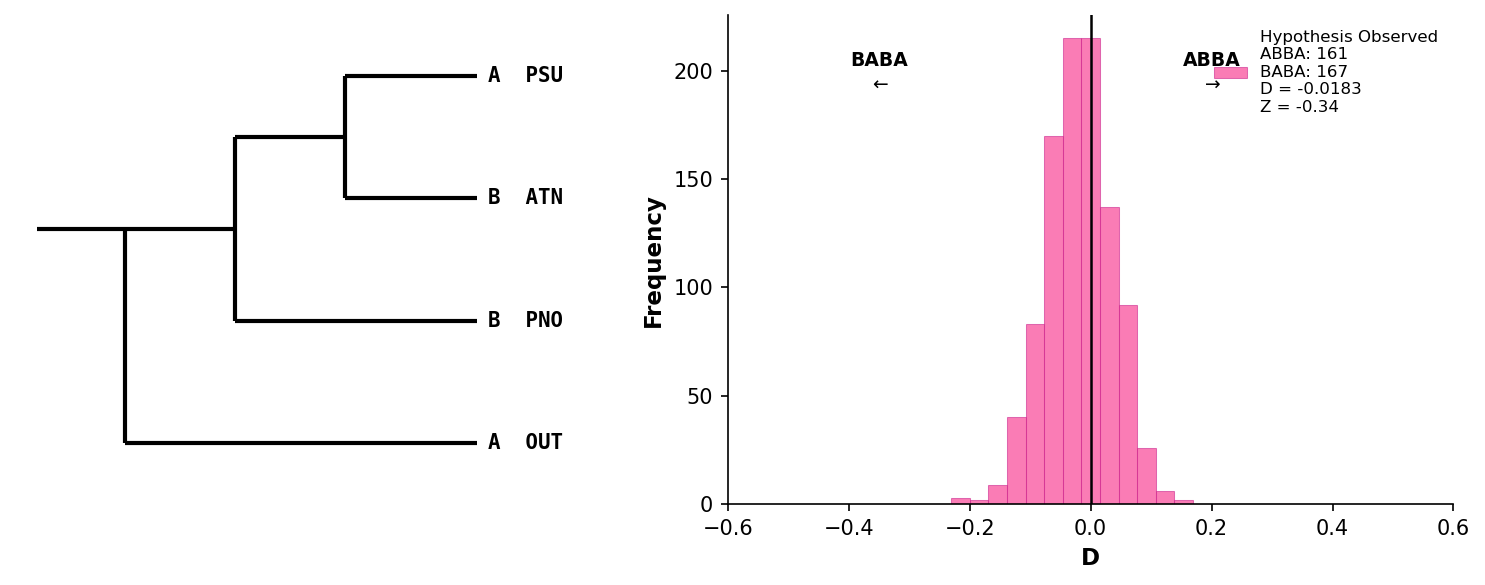


Procesando combinación: (((PCE, ATN), PNO), OUT)...
       RESULTADOS FINALES DEL TEST D      
 Hipótesis: (((PCE, ATN), PNO), OUT)
 Conteo Total Sitios ABBA : 152
 Conteo Total Sitios BABA : 222
 Estadístico D             : -0.1872
 Error Estándar (Bootstrap): 0.0500
 Z-score                   : -3.7427
 Significancia: Flujo génico significativo entre PCE y PNO


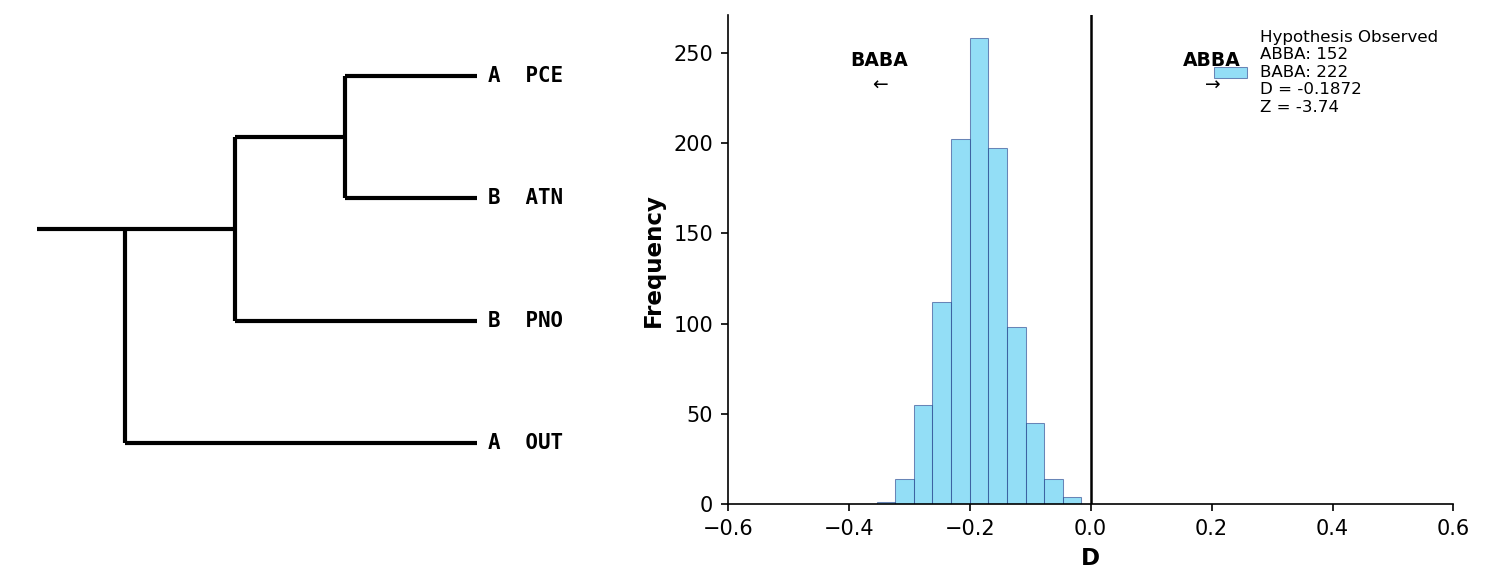


Procesando combinación: (((PCH, ATN), PNO), OUT)...
       RESULTADOS FINALES DEL TEST D      
 Hipótesis: (((PCH, ATN), PNO), OUT)
 Conteo Total Sitios ABBA : 82
 Conteo Total Sitios BABA : 81
 Estadístico D             : 0.0061
 Error Estándar (Bootstrap): 0.0808
 Z-score                   : 0.0759
 Significancia: No hay evidencia de flujo génico (ILS o estructura ancestral).


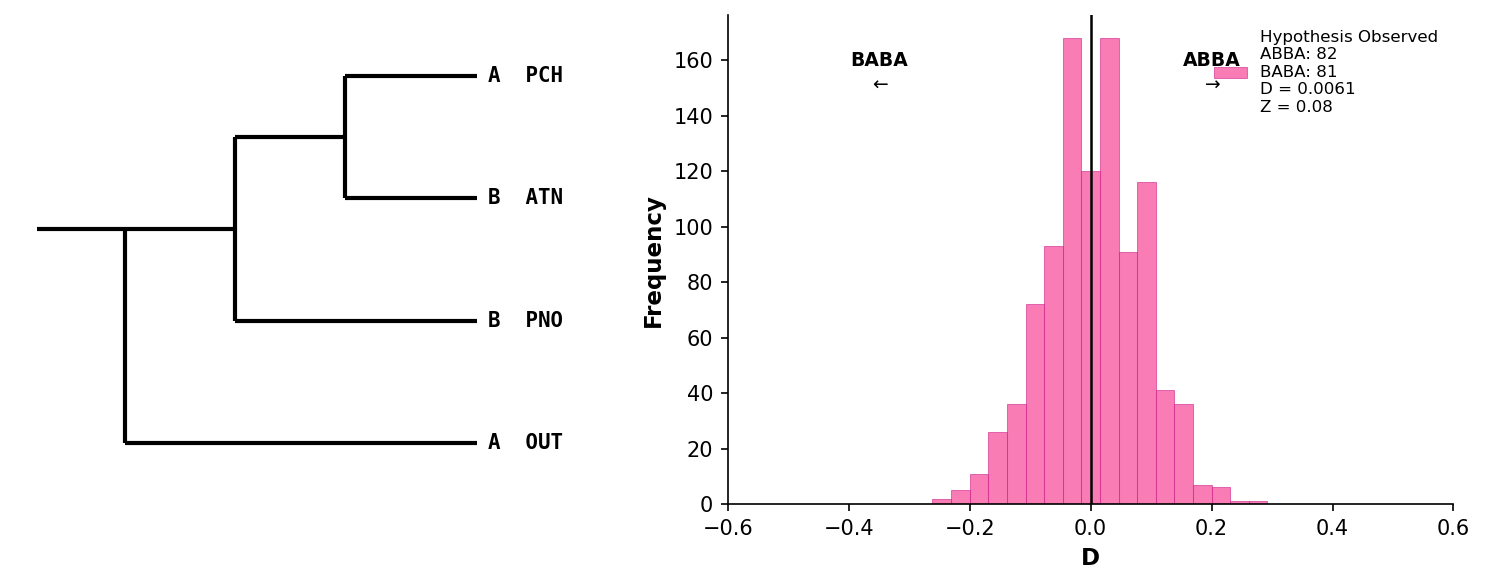


Procesando combinación: (((POO, ATN), PNO), OUT)...
       RESULTADOS FINALES DEL TEST D      
 Hipótesis: (((POO, ATN), PNO), OUT)
 Conteo Total Sitios ABBA : 155
 Conteo Total Sitios BABA : 195
 Estadístico D             : -0.1143
 Error Estándar (Bootstrap): 0.0524
 Z-score                   : -2.1795
 Significancia: No hay evidencia de flujo génico (ILS o estructura ancestral).


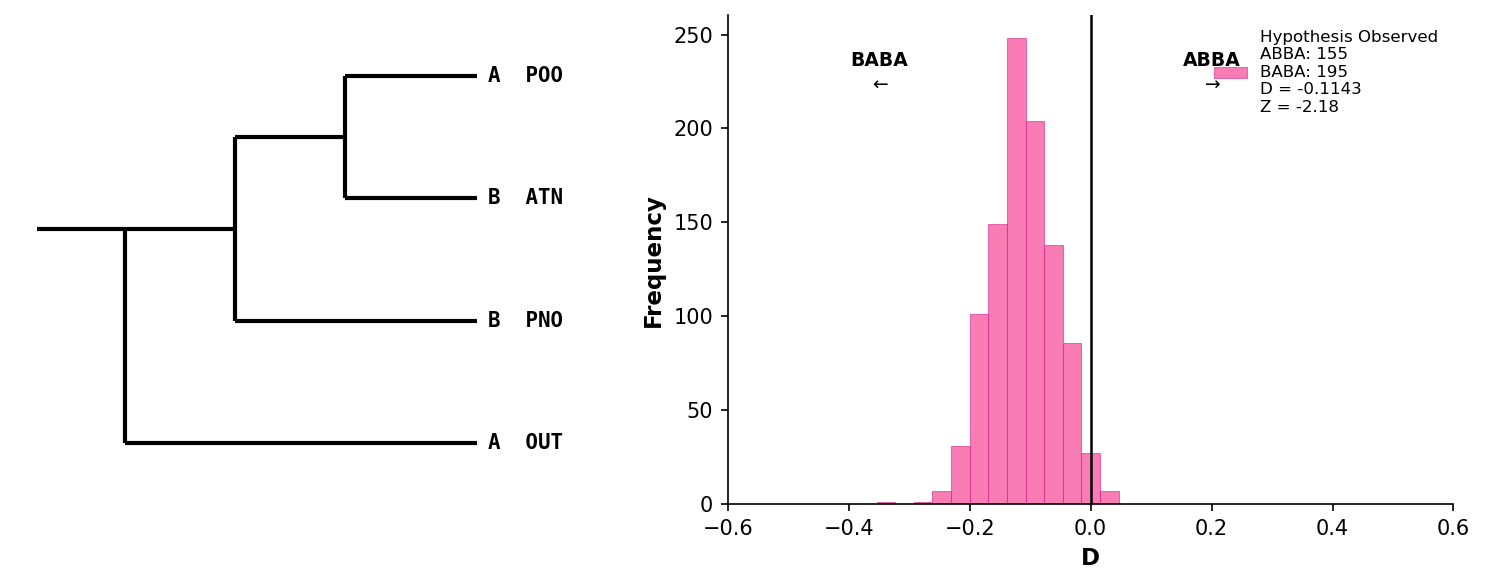


Procesando combinación: (((ISN, ATN), PNO), OUT)...
       RESULTADOS FINALES DEL TEST D      
 Hipótesis: (((ISN, ATN), PNO), OUT)
 Conteo Total Sitios ABBA : 97
 Conteo Total Sitios BABA : 93
 Estadístico D             : 0.0211
 Error Estándar (Bootstrap): 0.0715
 Z-score                   : 0.2945
 Significancia: No hay evidencia de flujo génico (ILS o estructura ancestral).


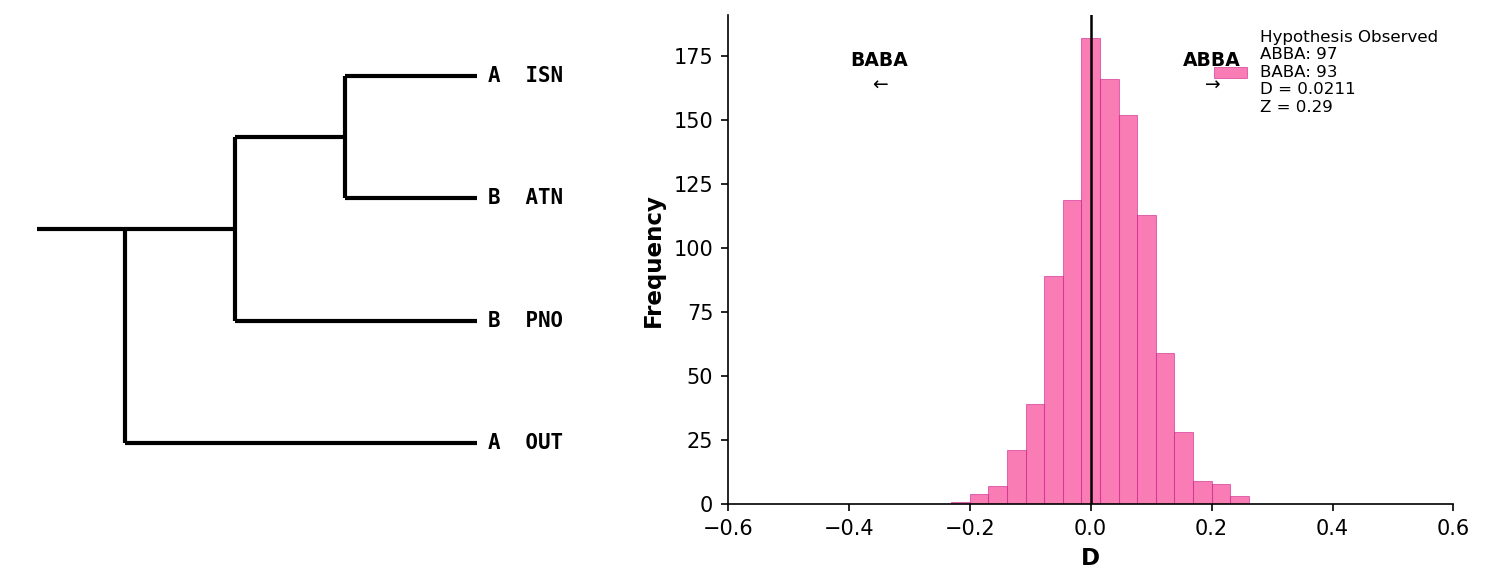


Procesando combinación: (((IST, ATN), PNO), OUT)...
       RESULTADOS FINALES DEL TEST D      
 Hipótesis: (((IST, ATN), PNO), OUT)
 Conteo Total Sitios ABBA : 80
 Conteo Total Sitios BABA : 117
 Estadístico D             : -0.1878
 Error Estándar (Bootstrap): 0.0702
 Z-score                   : -2.6767
 Significancia: No hay evidencia de flujo génico (ILS o estructura ancestral).


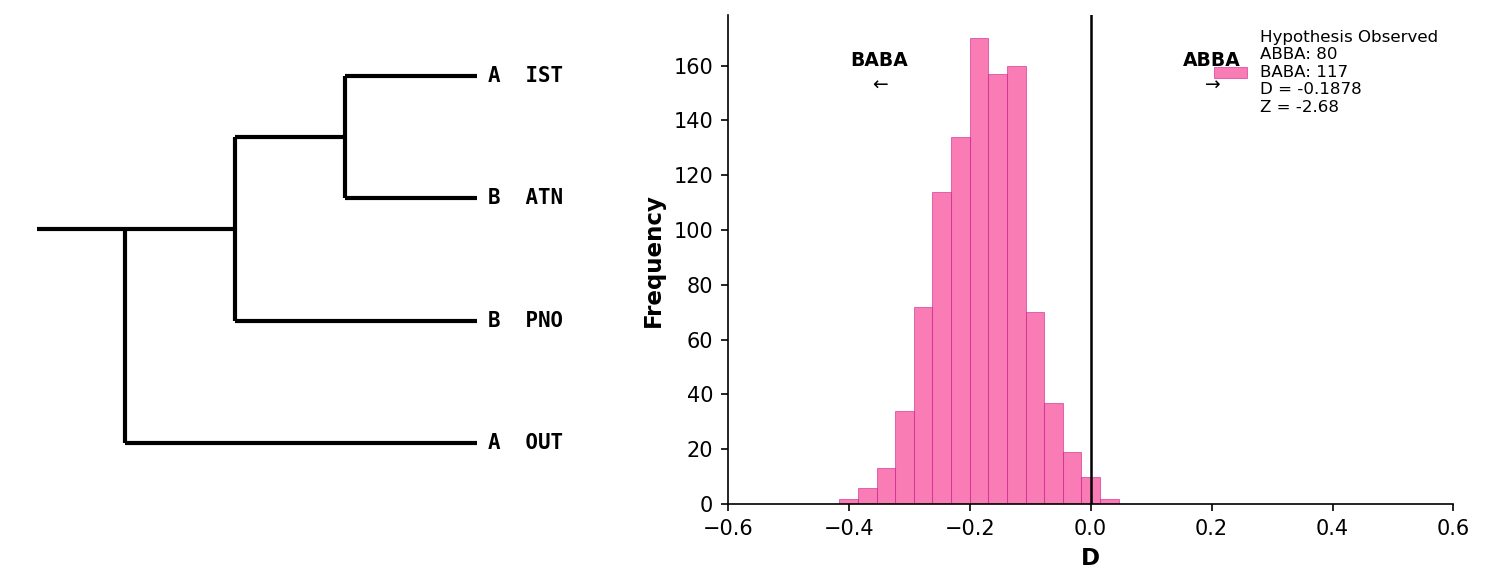


Procesando combinación: (((ACE, ATN), PNO), OUT)...
       RESULTADOS FINALES DEL TEST D      
 Hipótesis: (((ACE, ATN), PNO), OUT)
 Conteo Total Sitios ABBA : 97
 Conteo Total Sitios BABA : 109
 Estadístico D             : -0.0583
 Error Estándar (Bootstrap): 0.0702
 Z-score                   : -0.8300
 Significancia: No hay evidencia de flujo génico (ILS o estructura ancestral).


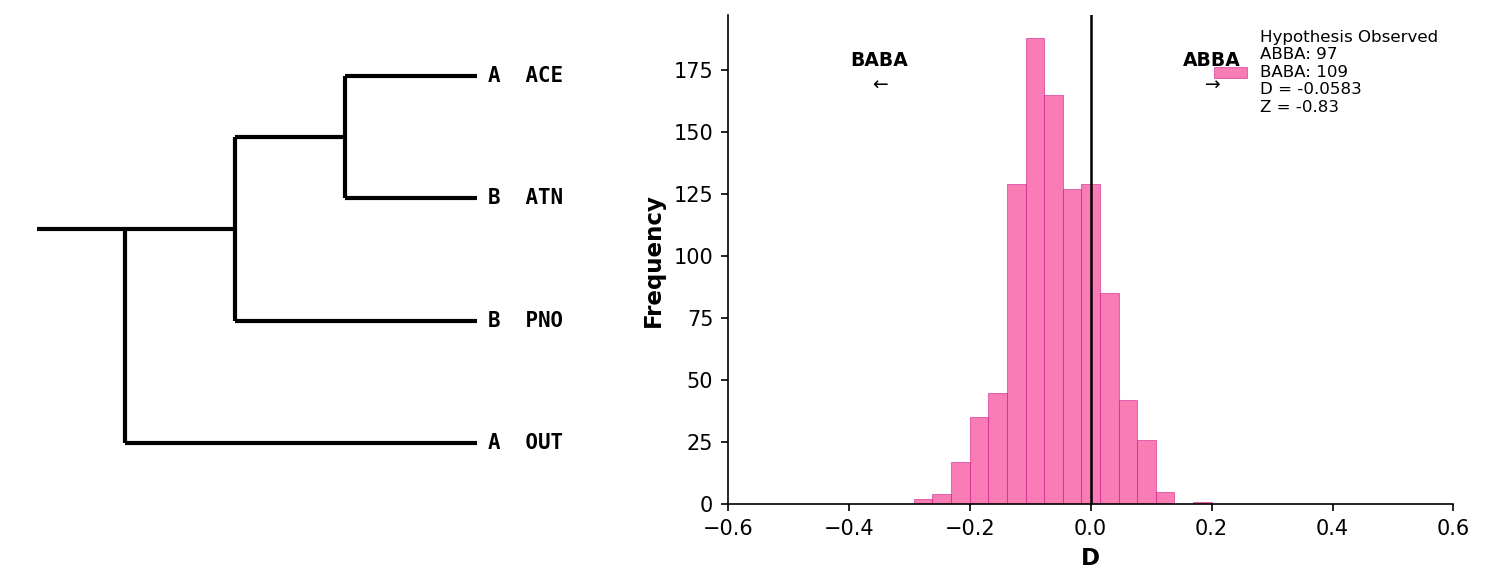


Procesando combinación: (((POR, ATN), PNO), OUT)...
       RESULTADOS FINALES DEL TEST D      
 Hipótesis: (((POR, ATN), PNO), OUT)
 Conteo Total Sitios ABBA : 168
 Conteo Total Sitios BABA : 191
 Estadístico D             : -0.0641
 Error Estándar (Bootstrap): 0.0534
 Z-score                   : -1.1993
 Significancia: No hay evidencia de flujo génico (ILS o estructura ancestral).


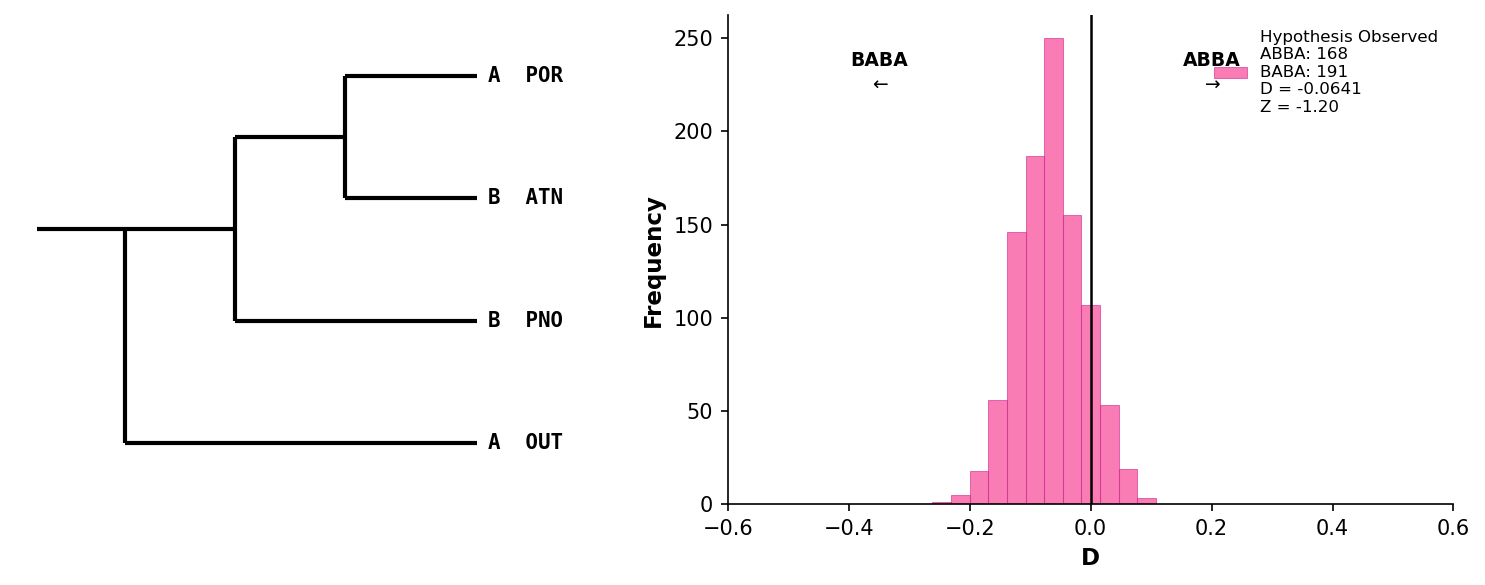


Procesando combinación: (((ACO, ATN), PNO), OUT)...
       RESULTADOS FINALES DEL TEST D      
 Hipótesis: (((ACO, ATN), PNO), OUT)
 Conteo Total Sitios ABBA : 111
 Conteo Total Sitios BABA : 123
 Estadístico D             : -0.0513
 Error Estándar (Bootstrap): 0.0657
 Z-score                   : -0.7808
 Significancia: No hay evidencia de flujo génico (ILS o estructura ancestral).


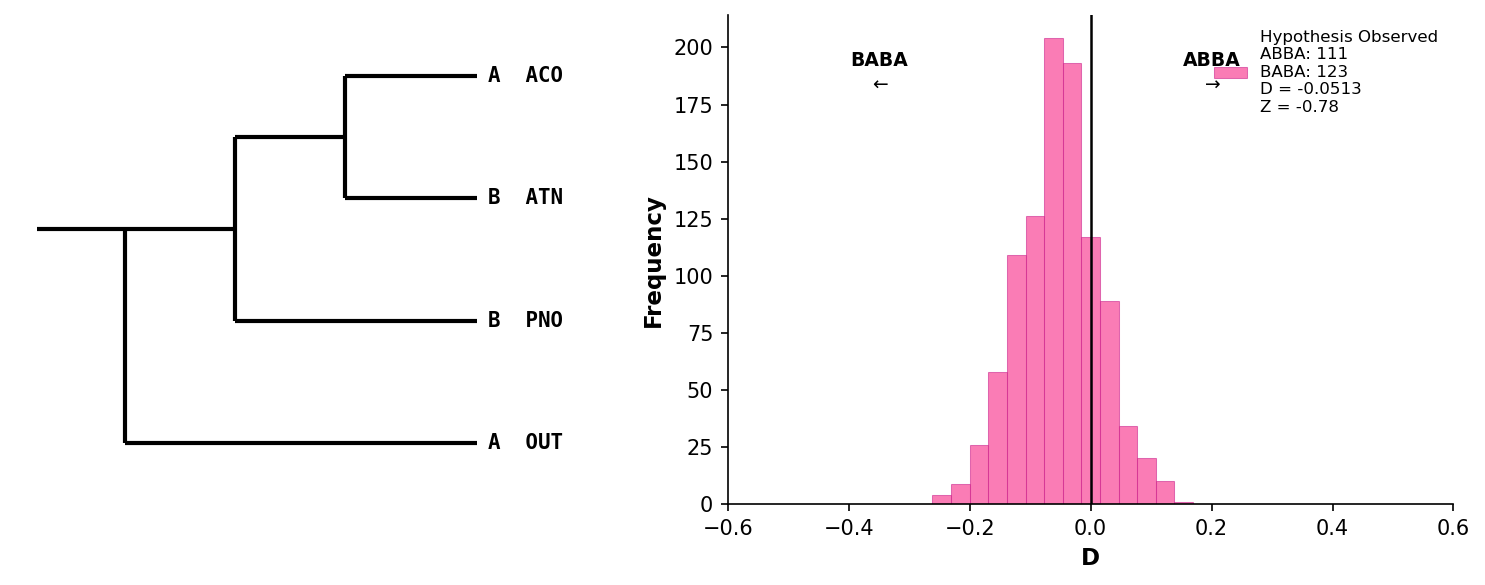


¡Análisis de todas las combinaciones completado con éxito!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import toytree

print("Iniciando análisis genómico e introgresión múltiple (Estilo Publicación)...")

# ==========================================
# 1. CARGAR Y ENRAIZAR EL ÁRBOL FILOGENÉTICO
# ==========================================
ruta_arbol = "/Users/itziliwi/JN_ABBA-BABA_micro/00_inputs/micro_iqtree_01out_20250728.nwk"
tree_obj = toytree.tree(ruta_arbol) 
muestras_en_arbol = list(tree_obj.get_tip_labels())

# Enraizar el árbol usando la API de toytree v3 (.mod.root)
arbol_enraizado = tree_obj.root("eIm_002")
arbol_string = arbol_enraizado.write()


# ==========================================
# 2. CARGAR MAPA DE POBLACIONES Y CONFIGURAR ROLES
# ==========================================
ruta_tsv = "/Users/itziliwi/JN_ABBA-BABA_micro/00_inputs/poblacion_260702.tsv" 
df = pd.read_csv(ruta_tsv, sep="\t", header=0)
df.columns = ["muestra", "poblacion"]
df["muestra"] = df["muestra"].astype(str).str.strip()
df["poblacion"] = df["poblacion"].astype(str).str.strip()

poblaciones_por_muestra = dict(zip(df["muestra"], df["poblacion"]))

# NUEVA CONFIGURACIÓN: Fijamos P2, P3 y P4
pob_P2 = "ATN"
pob_P3 = "PNO"
pob_P4 = "OUT"

# Obtener todas las poblaciones candidatas para P1 (excluyendo las fijas)
todas_las_poblaciones = df["poblacion"].unique()
poblaciones_P1 = [p for p in todas_las_poblaciones if p not in [pob_P2, pob_P3, pob_P4]]

# Asignar listas de muestras para las poblaciones que se quedan fijas
muestras_P2 = [m for m, p in poblaciones_por_muestra.items() if p == pob_P2]
muestras_P3 = [m for m, p in poblaciones_por_muestra.items() if p == pob_P3]
muestras_P4 = [m for m, p in poblaciones_por_muestra.items() if p == pob_P4]

# ==========================================
# 3. LEER EL ARCHIVO .LOCI EN MEMORIA (OPTIMIZACIÓN)
# ==========================================
# Almacenamos los loci en una lista de diccionarios para no re-leer el disco en cada iteración
ruta_loci = "/Users/itziliwi/JN_ABBA-BABA_micro/00_inputs/micro_c85_m95.loci"
print("Cargando archivo .loci en memoria...")

todos_los_loci = []
with open(ruta_loci, "r") as f:
    locus_actual = {}
    for linea in f:
        linea_limpia = linea.strip()
        if not linea_limpia:
            continue
        if linea_limpia.startswith("//"):
            if locus_actual:
                todos_los_loci.append(locus_actual)
            locus_actual = {}
        else:
            parts = linea_limpia.split()
            if len(parts) == 2:
                locus_actual[parts[0].replace(">", "")] = parts[1]


# ==========================================
# 4. ITERAR SOBRE CADA CANDIDATO PARA P1
# ==========================================
for pob_P1 in poblaciones_P1:
    print(f"\nProcesando combinación: ((({pob_P1}, {pob_P2}), {pob_P3}), {pob_P4})...")
    
    # Obtener muestras de la P1 actual en esta iteración
    muestras_P1 = [m for m, p in poblaciones_por_muestra.items() if p == pob_P1]
    
    # Si la población no tiene muestras asignadas, saltar
    if not muestras_P1:
        print(f"Saltando {pob_P1}: No se encontraron muestras.")
        continue
        
    loci_data = []
    
    # Procesar los loci guardados en memoria
    for locus in todos_los_loci:
        # Verificar que el locus tenga al menos una muestra de cada población
        if (any(m in locus for m in muestras_P1) and 
            any(m in locus for m in muestras_P2) and 
            any(m in locus for m in muestras_P3) and 
            any(m in locus for m in muestras_P4)):
            
            seq1 = next(locus[m] for m in muestras_P1 if m in locus)
            seq2 = next(locus[m] for m in muestras_P2 if m in locus)
            seq3 = next(locus[m] for m in muestras_P3 if m in locus)
            seq4 = next(locus[m] for m in muestras_P4 if m in locus)
            
            for n1, n2, n3, n4 in zip(seq1, seq2, seq3, seq4):
                if '-' in (n1, n2, n3, n4) or 'N' in (n1, n2, n3, n4):
                    continue
                # Patrón ABBA
                if n1 == n4 and n2 == n3 and n2 != n4:
                    loci_data.append(1)
                # Patrón BABA
                elif n2 == n4 and n1 == n3 and n1 != n4:
                    loci_data.append(-1)

    # ==========================================
    # 5. CÁLCULO ESTADÍSTICO Y BOOTSTRAP
    # ==========================================
    sitios_abba = loci_data.count(1)
    sitios_baba = loci_data.count(-1)
    total_sitios = sitios_abba + sitios_baba
    
    if total_sitios == 0:
        print(f"No se detectaron sitios informativos para la combinación con {pob_P2}.")
        continue
        
    D = (sitios_abba - sitios_baba) / total_sitios
    
    # Bootstrap
    np.random.seed(42)
    arr_data = np.array(loci_data)
    boot_ds = []
    
    for _ in range(1000):
        boot_sample = np.random.choice(arr_data, size=len(arr_data), replace=True)
        n_abba = np.sum(boot_sample == 1)
        n_baba = np.sum(boot_sample == -1)
        if (n_abba + n_baba) > 0:
            boot_ds.append((n_abba - n_baba) / (n_abba + n_baba))
            
    std_err = np.std(boot_ds) if len(boot_ds) > 0 else 0
    z_score = D / std_err if std_err > 0 else 0
    
    # Imprimir resultados en consola
    print("==========================================")
    print("       RESULTADOS FINALES DEL TEST D      ")
    print("==========================================")
    print(f" Hipótesis: ((({pob_P1}, {pob_P2}), {pob_P3}), {pob_P4})")
    print(f" Conteo Total Sitios ABBA : {sitios_abba}")
    print(f" Conteo Total Sitios BABA : {sitios_baba}")
    print(f" Estadístico D             : {D:.4f}")
    print(f" Error Estándar (Bootstrap): {std_err:.4f}")
    print(f" Z-score                   : {z_score:.4f}")
    if abs(z_score) >= 3:
        pob_flujo = pob_P2 if z_score > 0 else pob_P1
        print(f" Significancia: Flujo génico significativo entre {pob_flujo} y {pob_P3}")
    else:
        print(" Significancia: No hay evidencia de flujo génico (ILS o estructura ancestral).")
    print("==========================================")

    # ==========================================
    # 6. GENERAR GRÁFICO AUTOMÁTICO POR COMBINACIÓN
    # ==========================================
    fig, (ax_tree, ax_hist) = plt.subplots(1, 2, figsize=(10, 4), dpi=150, gridspec_kw={'width_ratios': [1, 1.2]})
    
    # PANEL A: Árbol Filogenético Dinámico
    ax_tree.hlines(y=3.5, xmin=3.0, xmax=4.2, color='black', linewidth=2)  # P1
    ax_tree.hlines(y=2.5, xmin=3.0, xmax=4.2, color='black', linewidth=2)  # P2
    ax_tree.hlines(y=1.5, xmin=2.0, xmax=4.2, color='black', linewidth=2)  # P3
    ax_tree.hlines(y=0.5, xmin=1.0, xmax=4.2, color='black', linewidth=2)  # P4
    
    ax_tree.hlines(y=3.0, xmin=2.0, xmax=3.0, color='black', linewidth=2)
    ax_tree.hlines(y=2.25, xmin=1.0, xmax=2.0, color='black', linewidth=2)
    ax_tree.hlines(y=2.25, xmin=0.2, xmax=1.0, color='black', linewidth=2)
    
    ax_tree.vlines(x=3.0, ymin=2.5, ymax=3.5, color='black', linewidth=2)
    ax_tree.vlines(x=2.0, ymin=1.5, ymax=3.0, color='black', linewidth=2)
    ax_tree.vlines(x=1.0, ymin=0.5, ymax=2.25, color='black', linewidth=2)
    
    ax_tree.text(4.3, 3.5, f"A  {pob_P1}", fontsize=10, va='center', fontweight='bold', family='monospace')
    ax_tree.text(4.3, 2.5, f"B  {pob_P2}", fontsize=10, va='center', fontweight='bold', family='monospace')
    ax_tree.text(4.3, 1.5, f"B  {pob_P3}", fontsize=10, va='center', fontweight='bold', family='monospace')
    ax_tree.text(4.3, 0.5, f"A  {pob_P4}", fontsize=10, va='center', fontweight='bold', family='monospace')
    
    ax_tree.set_xlim(0, 5.5)
    ax_tree.set_ylim(0, 4.0)
    ax_tree.axis('off')
    
    # PANEL B: Histograma
    bins_eje = np.linspace(-0.6, 0.6, 40)
    color_hist = '#4CC9F0' if abs(z_score) >= 3 else '#F72585'
    borde_hist = '#27408B' if abs(z_score) >= 3 else '#CD2990'
    
    texto_leyenda = f"Hypothesis Observed\nABBA: {sitios_abba}\nBABA: {sitios_baba}\nD = {D:.4f}\nZ = {z_score:.2f}"
    
    ax_hist.hist(boot_ds, bins=bins_eje, color=color_hist, alpha=0.6, edgecolor=borde_hist, linewidth=0.5, label=texto_leyenda)
    ax_hist.axvline(x=0, color='black', linewidth=1.2)
    
    altura_max = ax_hist.get_ylim()[1] if ax_hist.get_ylim()[1] > 0 else 1
    ax_hist.text(-0.35, altura_max * 0.85, 'BABA\n$\\leftarrow$', fontsize=9, fontweight='bold', ha='center')
    ax_hist.text(0.20, altura_max * 0.85, 'ABBA\n$\\rightarrow$', fontsize=9, fontweight='bold', ha='center')
    
    ax_hist.set_xlim(-0.6, 0.6)
    ax_hist.set_xlabel('D', fontsize=11, fontweight='bold')
    ax_hist.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax_hist.legend(loc='upper right', fontsize=8, frameon=False, bbox_to_anchor=(1.0, 1.0))
    ax_hist.spines['top'].set_visible(False)
    ax_hist.spines['right'].set_visible(False)
    
    plt.tight_layout()
    # Descomenta las líneas de abajo si quieres guardar los gráficos automáticamente
    # plt.savefig(f'figura_compuesta_{pob_P2}.png', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()

print("\n¡Análisis de todas las combinaciones completado con éxito!")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import toytree
import sys

# ==========================================
# CONTROL DE VERSIONES DEL ENTORNO
# ==========================================
print("=== VERSIONES DE SOFTWARE CORRIENDO ===")
print(f"Python     : {sys.version.split()[0]}")
print(f"toytree    : {toytree.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")
print("=======================================\n")

=== VERSIONES DE SOFTWARE CORRIENDO ===
Python     : 3.12.9
toytree    : 3.0.10
NumPy      : 1.26.4
Pandas     : 2.2.3

